Step 1 → Import libraries
Step 2 → Load Titanic dataset
Step 3 → Explore data
Step 4 → Clean data
Step 5 → Prepare X and y
Step 6 → Split train and test
Step 7 → Train Decision Tree
Step 8 → Check accuracy
Step 9 → Visualize the tree
Step 10→ Predict a new passenger!

In [3]:
# Step 1 → Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

In [4]:
# Step 2 → Load Titanic dataset
df=pd.read_csv('train.csv')

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [21]:
# Step 3 → Explore data
print(df.shape)

print(df.info())

df.describe()

(891, 12)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB
None


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [50]:
# Step 4 → Clean data
# df.isnull().sum()

df['Age']= df['Age'].fillna(df['Age'].mean())

df['Embarked']= df['Embarked'].fillna(df['Embarked'].mode()[0])

df= df.drop('Cabin', axis=1,errors='ignore')

df.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

In [78]:
# (Before training ANY ML model:
# → Remove useless columns
# → Convert ALL text to numbers)

df = df.drop(['PassengerId','Name','Ticket'],axis=1, errors='ignore')

df['Sex'] = df['Sex'].map({'male':0, 'female':1})
df['Embarked'] = df['Embarked'].map({'S':0, 'C':1, 'Q':2})


In [79]:
# Step 5 → Prepare X and y
X = df.drop('Survived',axis=1)
y = df['Survived']

print(X.shape)
print(y.shape)

(891, 7)
(891,)


In [80]:
# Step 6 → Split train and test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size= 0.2
)

print(len(X_train))
print(len(X_test))

712
179


In [97]:
# Step 7 → Train Decision Tree

model = DecisionTreeClassifier(max_depth=3, random_state=42)
model.fit(X_train, y_train)

print("Model Train Succesfully")

Model Train Succesfully


In [98]:
# Step 8 → Check accuracy
y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test,y_pred)

print("Score :",accuracy)

Score : 0.7430167597765364


In [1]:
# for depth in [2,3,4,5,6,7,8] :
#     model = DecisionTreeClassifier(max_depth=depth, random_state=42)
#     model.fit(X_train, y_train)
#     y_pred = model.predict(X_test)
#     accuracy = accuracy_score(y_test,y_pred)
#     print(f"Score -->{accuracy}  Depth -->{depth}")


# u can check by doing this

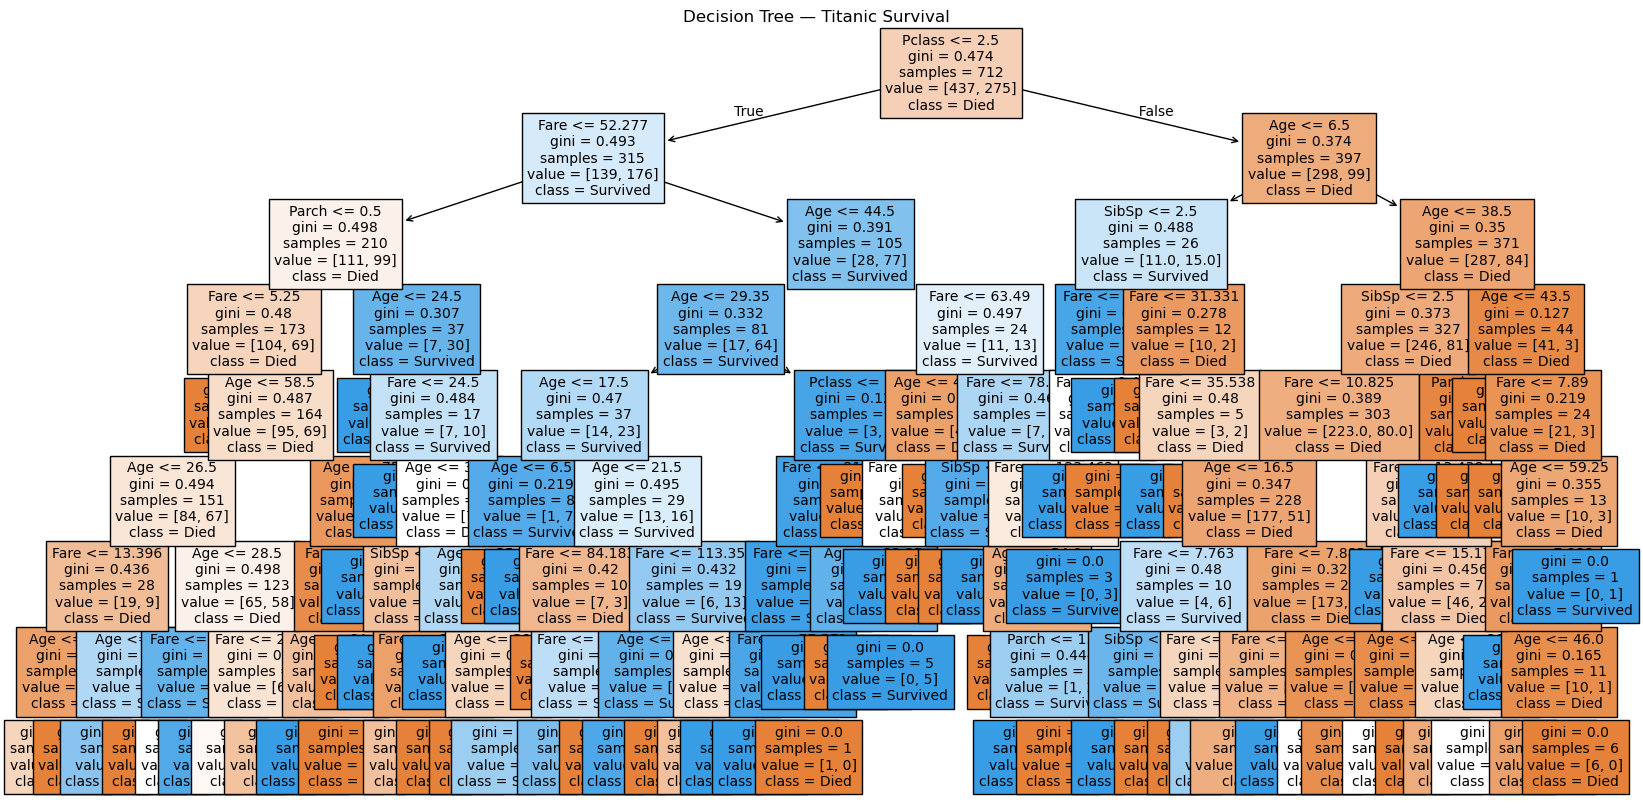

In [100]:
# Step 9 → Visualize the tree
plt.figure(figsize=(20,10))

plot_tree(
    model,
    feature_names=X.columns,
    class_names=['Died', 'Survived'],
    filled=True,
    fontsize=10
)
plt.title("Decision Tree — Titanic Survival")
plt.show()

In [112]:
# Step 10 Predict a new passenger!
new_passenger =pd.DataFrame({
     'Pclass'   : [1],      # Third class
    'Sex'      : [1],      # 0 = male
    'Age'      : [23],     # 22 years old
    'SibSp'    : [1],      # 1 sibling
    'Parch'    : [1],      # no parents
    'Fare'     : [18.00],   # cheap ticket
    'Embarked' : [0]       # S = Southampton
})

result = model.predict(new_passenger)

if (result==1) :
    print("Survived")
else :
    print("Died")

Survived
